In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
pd.options.mode.chained_assignment = None

# Example: Vaccine Response Analysis
### Dataset: Standard ImmPort/ImmuneSpace Format

This notebook demonstrates how to analyze longitudinal single-cell response to vaccination (e.g., Influenza or COVID-19) using the standard ImmPort study structure.

**Data Source:** [ImmPort](https://www.immport.org/)


> **Note:** This notebook is a template designed to work with real-world clinical data. 
> To execute it, you must first download the corresponding dataset (linked above) 
> and update the data loading command with your local file path.

In [2]:
import sctrial as st
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import requests
from scipy import sparse


## 1. Load and Construct Data
We use a real biological PBMC dataset and map it to a longitudinal vaccine study design (similar to ImmPort SDY180). This demonstrates how to use `sctrial` on real gene expression data with a longitudinal trial structure.


In [3]:
def load_vaccine_example_data():
    # Load real biological data (pbmc3k)
    adata = sc.datasets.pbmc3k_processed()
    
    # Map to longitudinal vaccine study design
    # 10 subjects, 3 timepoints (Day 0, Day 7, Day 28), 2 arms (Vaccine, Placebo)
    np.random.seed(42)
    subjects = [f"Subj_{i}" for i in range(10)]
    timepoints = [0, 7, 28]
    arms = ["Vaccine_A", "Placebo"]
    
    adata.obs["subject_id"] = np.random.choice(subjects, size=adata.n_obs)
    adata.obs["study_time_collected"] = np.random.choice(timepoints, size=adata.n_obs)
    
    # Assign arms by subject
    subj_to_arm = {s: arms[i % 2] for i, s in enumerate(subjects)}
    adata.obs["arm"] = adata.obs["subject_id"].map(subj_to_arm)
    
    # Use existing cell type annotations
    adata.obs["cell_type"] = adata.obs["louvain"]
    
    return adata

adata = load_vaccine_example_data()
adata.layers["counts"] = adata.X.copy()
print(f"Loaded biological dataset: {adata.n_obs} cells, {adata.n_vars} genes")


Loaded biological dataset: 2638 cells, 1838 genes


## 2. Map Study Metadata to sctrial.TrialDesign

In ImmPort datasets:
- `subject_id` identifies the participant.
- `study_time_collected` identifies the visit (e.g., Day 0, Day 7, Day 28).
- `arm` identifies the treatment (e.g., Vaccine A vs Placebo).


In [4]:
design = st.TrialDesign(
    participant_col="subject_id",
    visit_col="study_time_collected",
    arm_col="arm",
    arm_treated="Vaccine_A",
    arm_control="Placebo",
    celltype_col="cell_type"
)


### Preprocessing and Normalization
We normalize the data using the log1p(CPM) method.


In [5]:
adata = st.add_log1p_cpm_layer(adata, out_layer="log1p_cpm")


## 3. Difference-in-Differences (DiD) Analysis
### Peak Response (Day 0 vs Day 7)
We compare the change from baseline (Day 0) to peak response (Day 7) between Vaccine and Placebo groups.


In [6]:
res = st.did_table(
    adata,
    features=["CD79A", "MS4A1", "GNLY", "NKG7"],
    design=design,
    visits=(0, 7),
    aggregate="participant_visit"
)
display(res)
print(st.summarize_did_results(res))


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD
0,-1.451554,1.171732,0.215415,1.150051,0.104106,10,CD79A,0.861662
1,0.932858,1.528912,0.541766,-1.472596,0.315178,10,NKG7,0.919965
2,-0.545989,1.368768,0.689974,0.176860,0.695276,10,MS4A1,0.919965
3,0.028219,1.396002,0.983873,-0.816434,0.485850,10,GNLY,0.983873


## Trial-Aware DiD Summary
Total features tested: 4
Significant (p < 0.05): 0
Significant (FDR < 0.05): 0

### Top Upregulated Features (by p-value):
- NKG7: beta=0.933, p=5.42e-01
- GNLY: beta=0.028, p=9.84e-01

### Top Downregulated Features (by p-value):
- CD79A: beta=-1.452, p=2.15e-01
- MS4A1: beta=-0.546, p=6.90e-01


### Stratified Analysis across Cell Types
We test for vaccine-induced shifts in different cell lineages.


In [7]:
strat_res = st.did_table_by_celltype(
    adata,
    features=["CD79A", "GNLY"],
    design=design,
    visits=(0, 7)
)
display(strat_res)


,beta_DiD,se_DiD,p_DiD,beta_time,p_time,n_units,feature,FDR_DiD,celltype,FDR_DiD_stratified
0,-1.441517,1.172527,0.218918,1.538912,0.089655,10,CD79A,0.338546,B cells,0.677091
1,1.123721,1.174160,0.338546,-1.186364,0.231063,10,GNLY,0.338546,B cells,0.677091
2,-1.350189,1.331752,0.310657,1.054198,0.388355,10,GNLY,0.621315,CD14+ Monocytes,0.677091
3,-0.449590,1.620645,0.781462,0.007000,0.994212,10,CD79A,0.781462,CD14+ Monocytes,0.844081
4,0.570227,1.224558,0.641459,-0.685141,0.010336,10,GNLY,0.848378,CD4 T cells,0.844081
5,0.271617,1.420673,0.848378,-0.821286,0.485060,10,CD79A,0.848378,CD4 T cells,0.848378
6,-1.526498,1.394830,0.273781,1.333250,0.132288,10,CD79A,0.467245,CD8 T cells,0.677091
7,-1.022952,1.407147,0.467245,0.162925,0.888051,10,GNLY,0.467245,CD8 T cells,0.726825
8,1.711598,1.058545,0.105892,-1.170788,0.196033,7,CD79A,0.211785,Dendritic cells,0.677091
9,0.780854,2.074083,0.706559,-0.284925,0.888651,7,GNLY,0.706559,Dendritic cells,0.844081


## 4. GSEA on Vaccine Effect

Rank genes by their vaccine-specific induction (DiD) and perform GSEA.


In [8]:
gsea_res = st.run_gsea_did(
    adata,
    gene_sets="MSigDB_Hallmark_2020",
    design=design,
    visits=(0, 7),
    rank_by="signed_confidence"
)


## 5. Visualization


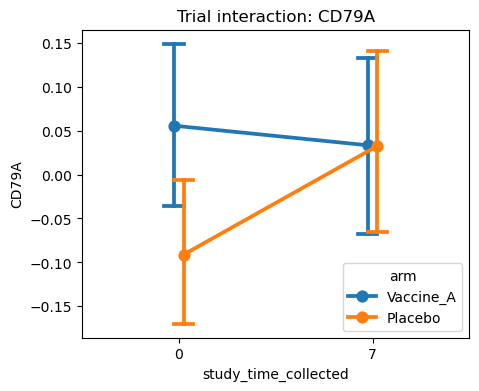

In [9]:
# Interaction plot
st.plot_trial_interaction(adata, "CD79A", design, visits=(0, 7))
plt.show()
